# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from PIL import Image
from matplotlib import pyplot as plt



In [2]:
# ── Load image ────────────────────────────────────
from google.colab import files
uploaded = files.upload()


Saving image3.png to image3.png


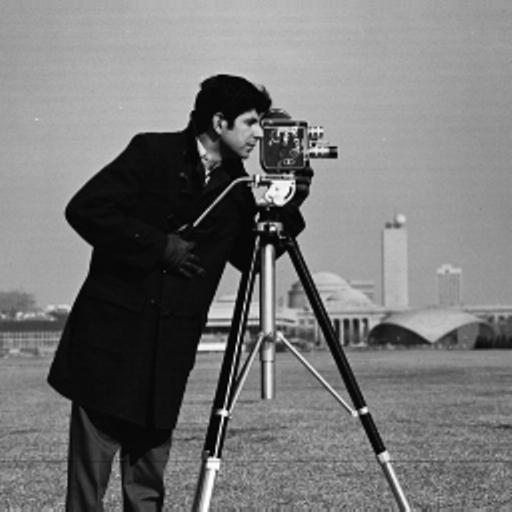

In [3]:
img = cv2.imread('image3.png')
cv2_imshow(img)


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [5]:
img = Image.open('image3.png')

# Get the size of the image
width, height = img.size

# scaling factors
scale_factor = 2

In [6]:
# — 1. Increase size (scale x2) ————————————————

# Resize the image using PIL's built-in method
new_size = (width * scale_factor, height * scale_factor)
scaled_img = img.resize(new_size, resample=Image.LANCZOS)



Original size: 512x512
New size: (1024, 1024)


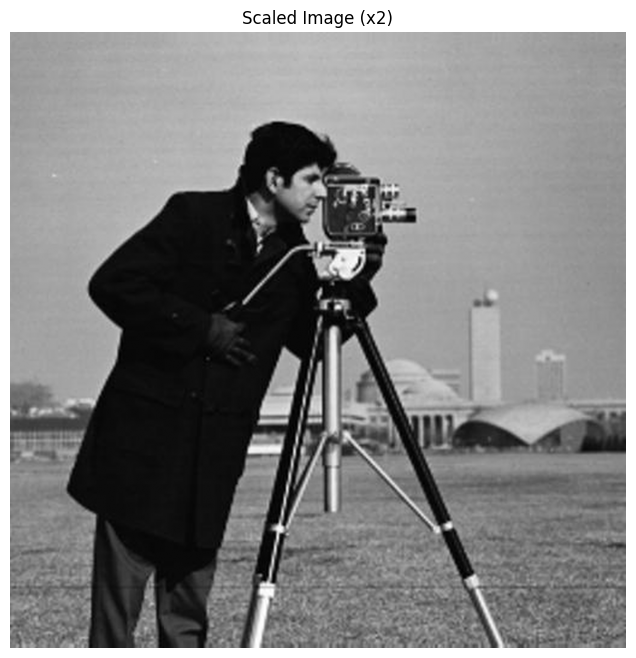

In [24]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save('task1_1_scaled.jpg')

print(f"Original size: {width}x{height}")
print(f"New size: {scaled_img.size}")


scaled_img.show()


plt.figure(figsize=(8, 8))
plt.imshow(scaled_img)
plt.title('Scaled Image (x2)')
plt.imshow(scaled_img, cmap='gray')
plt.axis('off')
plt.show()


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

Original size: 512x512
Stretched size: (1024, 512)


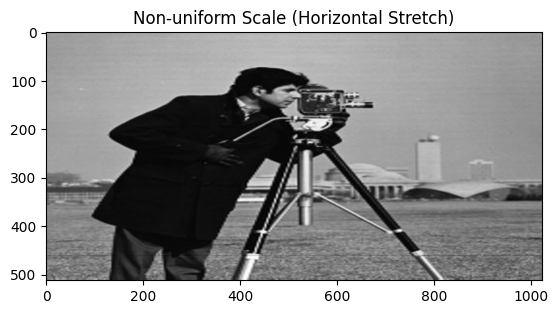

In [27]:
# --- non-uniform scale (cx=2, cy=1) → stretch horizontally only ---

width, height = img.size


new_width = int(width * 2)
new_height = int(height * 1)


stretched_img = img.resize((new_width, new_height), resample=Image.LANCZOS)

stretched_img.save('task1_1_stretched.jpg')


print(f"Original size: {width}x{height}")
print(f"Stretched size: {stretched_img.size}")

plt.imshow(stretched_img)
plt.title('Non-uniform Scale (Horizontal Stretch)')
plt.imshow(stretched_img, cmap='gray')
plt.show()

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [8]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
# — 2. Rotate 120 degrees ————————————————


rotated_img = img.rotate(120, expand=True)


Original size: (512, 512)
Rotated image size (with expansion): (700, 700)


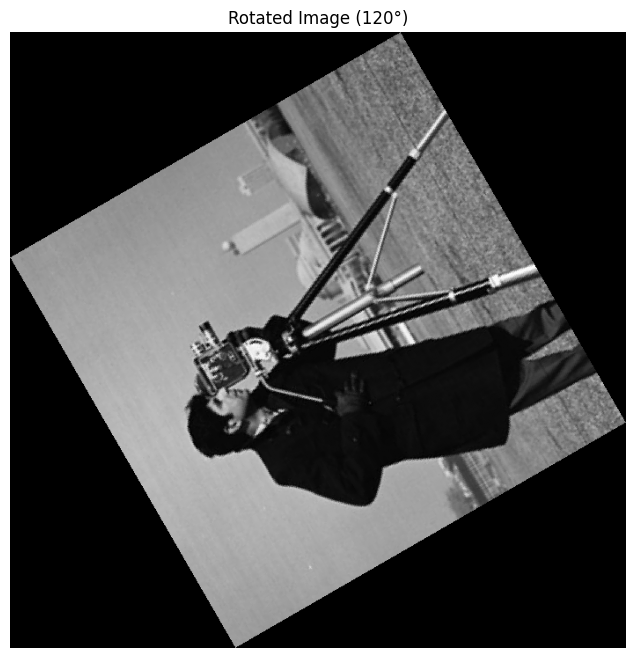

In [23]:



rotated_img.save('task1_2_rotated.jpg')

print(f"Original size: {img.size}")
print(f"Rotated image size (with expansion): {rotated_img.size}")


plt.figure(figsize=(8, 8))
plt.imshow(rotated_img)
plt.title('Rotated Image (120°)')
plt.axis('off')
plt.imshow(rotated_img, cmap='gray')

plt.show()

### 3. Shear

In [13]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size


In [14]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5
tx = -shx * width / 2

In [15]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform((int(width*1.5), height), Image.AFFINE, (1, shx, tx, 0, 1, 0))

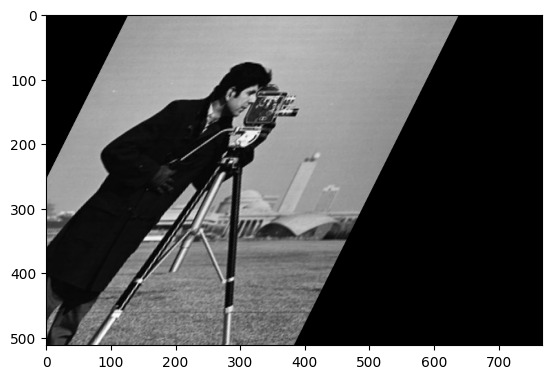

In [25]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save('task1_3_sheared.jpg')
plt.imshow(sheared_img)
plt.imshow(sheared_img, cmap='gray')
plt.show()

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

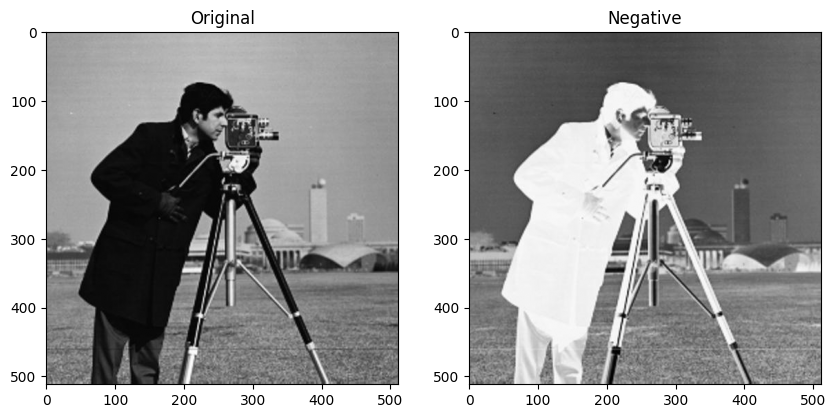

In [28]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation

import matplotlib.pyplot as plt
from PIL import ImageOps


img_array = np.array(img)
negative_numpy = 255 - img_array
negative_img = Image.fromarray(negative_numpy)


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(negative_img, cmap='gray')
plt.title('Negative')
plt.show()

negative_img.save('task2_1_negative.jpg')


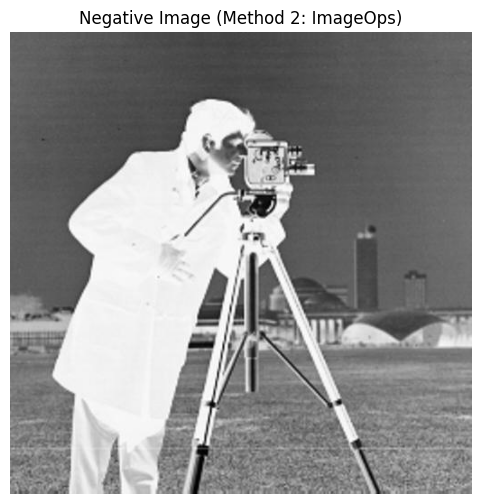

In [31]:
# --- Method 2: PIL's ImageOps -----------------------
from PIL import ImageOps


negative_img2 = ImageOps.invert(img.convert('RGB'))


import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(negative_img2)
plt.title('Negative Image (Method 2: ImageOps)')
plt.axis('off')
plt.show()

negative_img2.save('task2_1_negative.jpg')

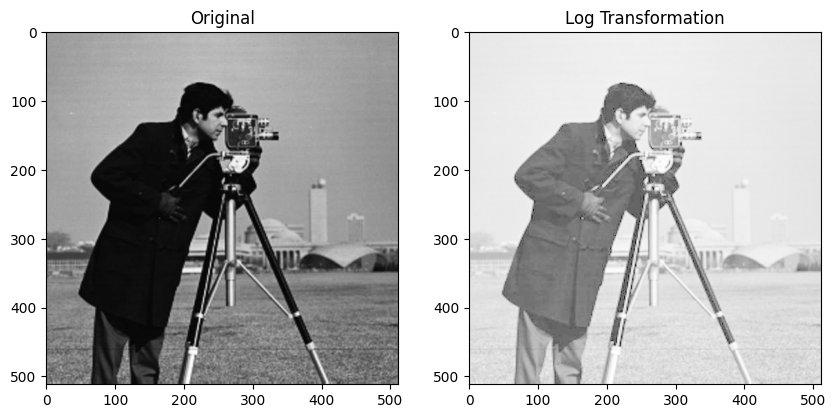

In [29]:
# --- 2. Log transformation -----------------------
r = np.array(img, dtype=float)
c = 255 / np.log(1 + np.max(r))
log_transformed_arr = c * np.log(1 + r)
log_img = Image.fromarray(np.uint8(log_transformed_arr))


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(log_img, cmap='gray')
plt.title('Log Transformation')
plt.show()

log_img.save('task2_2_log.jpg')


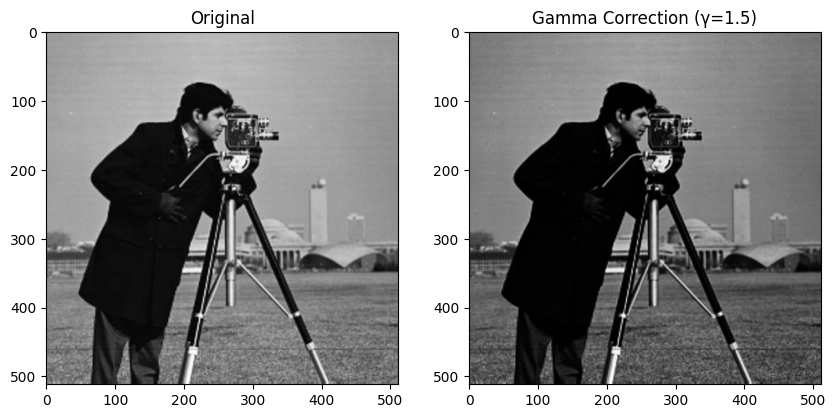

In [30]:

# --- 3. Power-law / Gamma correction -------------
gamma = 1.5
r = np.array(img, dtype=float)
c = 255 / (255**gamma)
gamma_corrected = c * (r**gamma)
gamma_img = Image.fromarray(np.uint8(gamma_corrected))


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(gamma_img, cmap='gray')
plt.title(f'Gamma Correction (γ={gamma})')
plt.show()

gamma_img.save('task2_3_gamma.jpg')
